# Logistic Regression
Partiamo dalla Logistic Regression con soft max. 
Pensiamo il problema posto come il seguente: "posso prevedere come sarà l'indice di qualità dell'aria tra un'ora attorno ad una data stazione, usando informazioni dell'arpav e dell'appa per le ore a questa precedenti?"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics

import sys
sys.path.append('../..')

import src.class_funcs as fs

Iniziamo lo studio partendo dal dataframe creato per l'EDA. Usiamo come feature la stazione, l'elevazione, il giorno, l'ora ed i dati riferiti all'inquinamento atmosferico e al meteo per le tre ore antecedenti l'ora considerata.
Visto che abbiamo notato che la correlazione con le precipitazioni è più rilevante dopo 5 ore, per queste ultime consideriamo i dati di 5, 6 e 7 ore prima

In [147]:
# prepariamo il dataframe per questo studio (poi questa parte va probabilmente spostata)
dataset_df = pd.read_csv('../../data/processed/dataset_EDA_processed.csv')
# voglio trasformare la data in un numero da 1 al massimo
dataset_df["date"] = pd.to_datetime(dataset_df["date"])
dataset_df["day"] = (dataset_df["date"] - dataset_df["date"].min()).dt.days + 1
dataset_df = dataset_df.drop(columns='date')

# cambiamo i giorni della settimana nel nome dei giorni
dataset_df["week_day"] = dataset_df["week_day"].astype(str)
day = {'0':'lunedì', '1':'martedì', '2':'mercoledì', '3':'giovedì', '4':'venerdì', '5':'sabato', '6':'domenica'}
dataset_df['week_day'] = dataset_df['week_day'].map(day)

# inseriamo l'AQI e togliamo le colonne di inquinanti non misurate da tutte le stazioni
inq_intervals = {'PM2.5':[(0, 10), (10, 20), (20, 25), (25, 30), (30, np.inf)], 
            'PM10':[(0, 20), (20, 35), (35, 50), (50, 100), (100, np.inf)],
            'NO2':[(0, 40), (40, 100), (100, 200), (200, 400), (400, np.inf)],
            'O3':[(0, 80), (80, 120), (120, 180), (180, 240), (240, np.inf)],
            'SO2':[(0, 100), (100, 200), (200, 350), (350, 500), (500, np.inf)],
            'CO':[(0, 5), (5, 7.5), (7.5, 10), (10, 20), (20, np.inf)]}

for inq in inq_intervals.keys():
    dataset_df['AQI_' + inq] = dataset_df[inq].apply(lambda x: fs.get_AQI_inq(x, inq_intervals[inq]))

AQI_cols = ['AQI_' + inq for inq in inq_intervals.keys()]

dataset_df['AQI'] = dataset_df[AQI_cols].max(axis=1)
dataset_df = dataset_df.drop(columns=AQI_cols)
# devo togliere i nan => tolgo tutte le colonne di inquinanti che non sono misurati da tutte le stazioni (rimangono solo PM10 e NO2)
# se necessario, stiamo già tenendo conto del contributo degli altri inquinanti nell'AQI 
dataset_df = dataset_df.drop(columns=['CO', 'O3', 'PM2.5', 'SO2'])

# tengo solo le colonne che mi interessano
feature_cols = ['station_appa', 'day', 'hour', 'week_day', 'elevation', 'PM10', 'NO2', 'AQI', 'tot_area_power', 'temperature', 'precipitation']
dataset_df = dataset_df[feature_cols + ['EAQI']]

target = dataset_df['EAQI']

dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,EAQI
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,fair
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,fair
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,fair
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,fair
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,fair


## Studio binario
Se considerassimo tutte le classi EAQI avremmo uno studio multiclasse con 5 classi. Per mettere in pratica le conoscienze sviluppate nel corso delle lezioni preferiamo però iniziare da uno studio binario, sostituendo la colonna EAQI con una semplice indicazione sulla bontà dell'aria: 0 = 'not ok' e 1 = 'ok',
dove viene considerato 'ok' tutto quello che ha AQI <= 50 e 'not ok' tutto quello che ha AQI > 50

In [148]:
threshold = 50
dataset_df['target'] = (dataset_df['AQI'] <= threshold).astype(int)
dataset_df = dataset_df.drop(columns='EAQI')
dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,target
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,1
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,1
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,1
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,1
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,1


Costruiamo quindi il dataframe inserendo le ore precedenti a quella di target come specificato sopra

In [153]:
feature_df = dataset_df[feature_cols[:5]].copy()
for h in range (1,4):
    feature_df[[col + f'_{h}' for col in feature_cols[5:10]]] = dataset_df.groupby('station_appa')[feature_cols[5:10]].shift(h)
    feature_df[f'precipitation_{4 + h}'] = dataset_df.groupby('station_appa')[feature_cols[-1]].shift(5 + h)

# trasformiamo in one-hot le stazioni ed il giorno della settimana
feature_df = pd.get_dummies(feature_df, columns=['week_day'], prefix='', prefix_sep='')
feature_df = pd.get_dummies(feature_df, columns=['station_appa'], prefix='', prefix_sep='')

classification_df = feature_df.copy()
classification_df['target'] = dataset_df['target']
classification_df = classification_df.dropna(subset=['precipitation_7'])

feature_cols = classification_df.columns.difference(['target'])

# vediamo se ci sono righe con nan e togliamole
classification_df = classification_df[~classification_df.isna().any(axis=1)]

classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,1
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,1
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,1
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,1
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,1


In [154]:
# creo train, valid e test
X_train, X_test, y_train, y_test= train_test_split(classification_df[feature_cols], classification_df['target'], test_size=0.2, random_state=12)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,sabato,temperature_1,temperature_2,temperature_3,tot_area_power_1,tot_area_power_2,tot_area_power_3,venerdì
4481,-0.494027,-0.508842,-0.635002,False,False,0.531191,0.502242,-0.068977,-0.668280,-0.624365,...,-0.203446,-0.204153,False,0.884977,1.070297,1.234716,0.261968,0.291952,0.317567,False
762,0.725489,0.947257,1.820469,True,False,-0.166898,-0.101756,-0.005424,0.856459,1.159965,...,-0.203446,-0.204153,False,-1.682592,-1.663495,-1.574727,-0.542594,-0.545691,-0.550840,False
2129,-0.666944,-0.690855,-0.580436,False,True,-1.245763,-1.246173,-1.244710,-1.001817,-1.010166,...,-0.203446,-0.204153,False,0.178306,-0.060927,-0.299854,-1.316289,-1.316471,-1.316610,False
5097,-0.694246,-0.363232,-0.034776,False,False,0.023490,0.247927,0.630107,-0.382392,-0.190339,...,-0.203446,-0.204153,False,0.508086,0.339715,-0.252636,0.450001,0.445460,0.441900,False
1208,1.817594,1.820917,1.820469,True,False,-0.325555,-0.292492,-0.259637,1.332940,1.256415,...,-0.203446,-0.204153,False,0.248973,0.221879,0.219539,-0.770440,-0.767931,-0.767515,False


In [155]:
# inizializziamo il classificatore
LR_cv = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=1000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced'             # bilancia in automatico le classi in base alla frequenza di input
)

In [156]:
# alleniamo il modello sul nostro insieme di training
LR_cv.fit(scaled_X_train,y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

<Axes: >

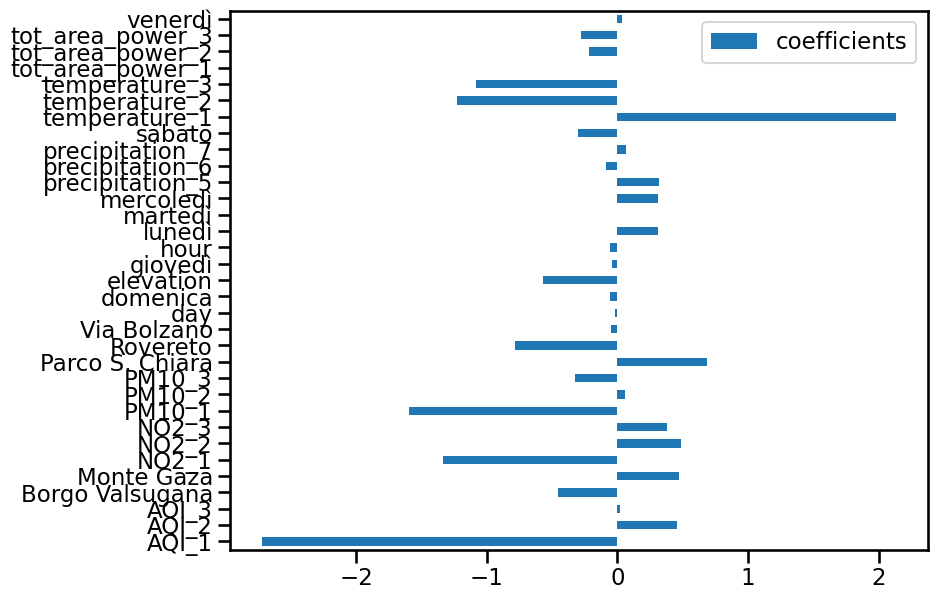

In [158]:
# diamo un'occhiata ai pesi per ciascuna feature in modo da capire quali siano le feature importanti e quali invece quelle inutili
coefs_df = pd.DataFrame(LR_cv.coef_.T,columns=['coefficients'],index=feature_cols)
coefs_df.plot.barh(figsize=(9,7))

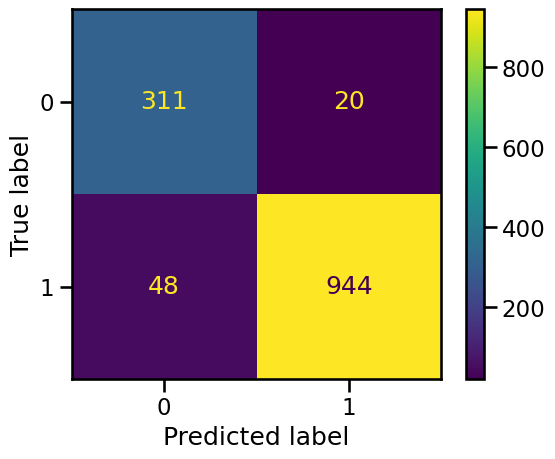

In [159]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR_cv.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=LR_cv.classes_)

plt.show()

In [161]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred)
recall      = metrics.recall_score      (y_test, y_pred)
f1_score    = metrics.f1_score          (y_test, y_pred)
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.9486016628873771
0.979253112033195
0.9516129032258065
0.9652351738241309
0.868069242154491


<Axes: >

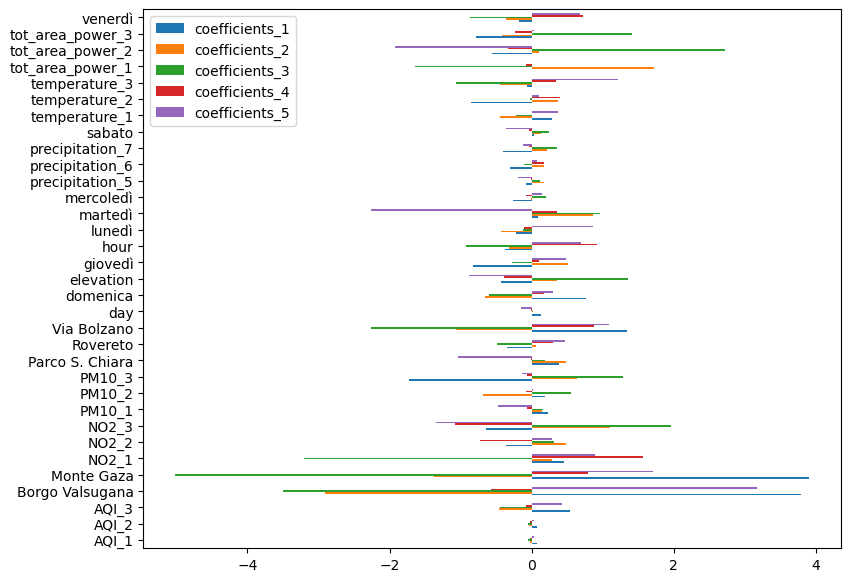

In [28]:
df_coef = pd.DataFrame(logreg.coef_.T,columns=['coefficients_1', 'coefficients_2', 'coefficients_3', 'coefficients_4', 'coefficients_5'],index=classification_features)
df_coef.plot.barh(figsize=(9,7))

In [29]:
y_pred = logreg.predict(scaled_test)
conf_mat  = confusion_matrix(test['target'], y_pred)
ConfusionMatrixDisplay(conf_mat, display_labels=logreg.classes_)
plt.show()

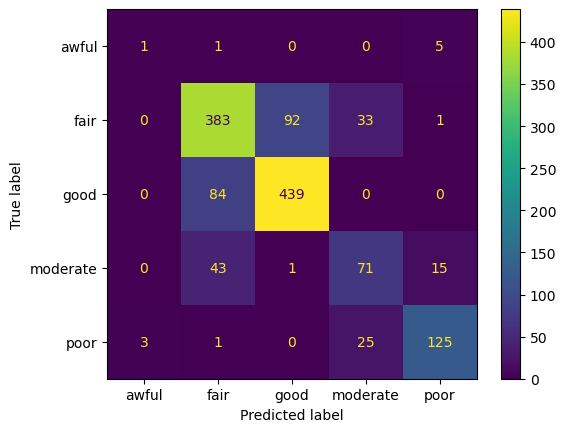

In [30]:
ConfusionMatrixDisplay.from_predictions(
    test['target'],
    y_pred,
    display_labels=logreg.classes_
)

plt.show()

# Per facilità di studio, rifacciamo il conto con solamente due classi

In [37]:
map2d = {'good': 'ok', 'fair': 'ok', 'moderate': 'ok', 'poor': 'not ok', 'awful': 'not ok'}
classification_df['target'] = classification_df['target'].map(map2d)

classification_df.head()



,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,ok
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,ok
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,ok


In [41]:
# creo train, valid e test
feature_cols = classification_df.columns.difference(['target'])
X_train, X_test, y_train, y_test= train_test_split(classification_df[feature_cols], classification_df['target'], test_size=0.2, random_state=12)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,sabato,temperature_1,temperature_2,temperature_3,tot_area_power_1,tot_area_power_2,tot_area_power_3,venerdì
4481,-0.494027,-0.508842,-0.635002,False,False,0.531191,0.502242,-0.068977,-0.668280,-0.624365,...,-0.203446,-0.204153,False,0.884977,1.070297,1.234716,0.261968,0.291952,0.317567,False
762,0.725489,0.947257,1.820469,True,False,-0.166898,-0.101756,-0.005424,0.856459,1.159965,...,-0.203446,-0.204153,False,-1.682592,-1.663495,-1.574727,-0.542594,-0.545691,-0.550840,False
2129,-0.666944,-0.690855,-0.580436,False,True,-1.245763,-1.246173,-1.244710,-1.001817,-1.010166,...,-0.203446,-0.204153,False,0.178306,-0.060927,-0.299854,-1.316289,-1.316471,-1.316610,False
5097,-0.694246,-0.363232,-0.034776,False,False,0.023490,0.247927,0.630107,-0.382392,-0.190339,...,-0.203446,-0.204153,False,0.508086,0.339715,-0.252636,0.450001,0.445460,0.441900,False
1208,1.817594,1.820917,1.820469,True,False,-0.325555,-0.292492,-0.259637,1.332940,1.256415,...,-0.203446,-0.204153,False,0.248973,0.221879,0.219539,-0.770440,-0.767931,-0.767515,False


In [49]:
# inizializziamo il classificatore
LR_cv = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=1000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced'             # bilancia in automatico le classi in base alla frequenza di input
)

In [50]:
# alleniamo il modello sul nostro insieme di training

LR_cv.fit(scaled_X_train,y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

<Axes: >

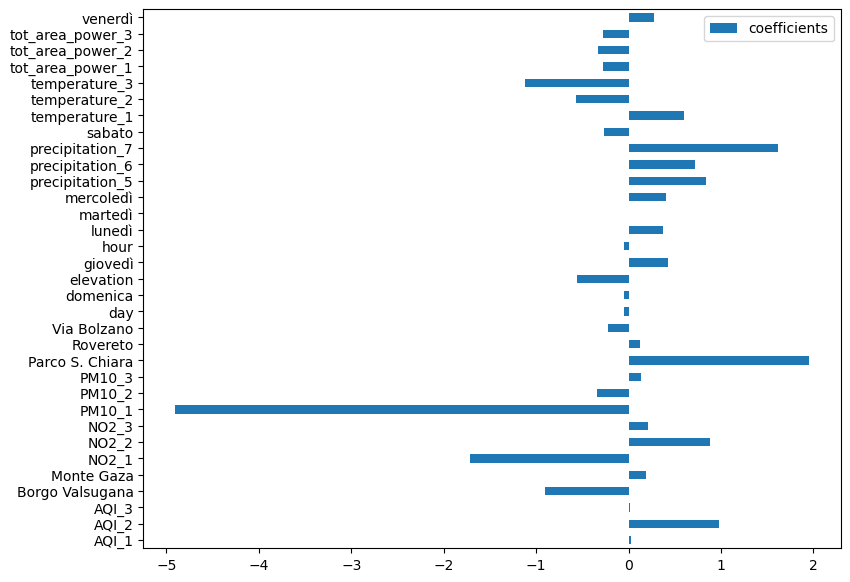

In [52]:
# diamo un'occhiata ai pesi per ciascuna feature in modo da capire quali siano le feature importanti e quali invece quelle inutili
coefs_df = pd.DataFrame(LR_cv.coef_.T,columns=['coefficients'],index=feature_cols)
coefs_df.plot.barh(figsize=(9,7))

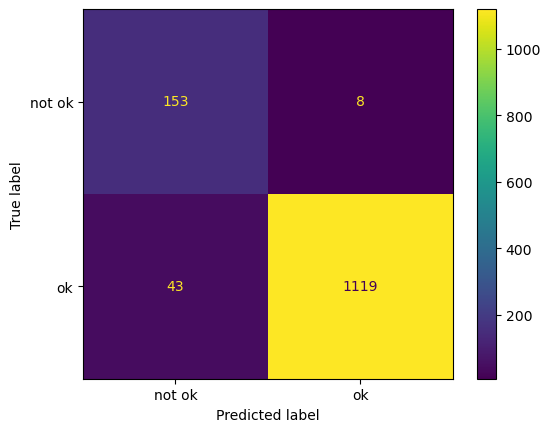

In [56]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR_cv.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=LR_cv.classes_ # tira fuori i nomi delle classi
)

plt.show()

In [ ]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred, pos_label='ok')
recall      = metrics.recall_score      (y_test, y_pred, pos_label='ok')
f1_score    = metrics.f1_score          (y_test, y_pred, pos_label='ok')
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.9614512471655329
0.9929015084294588
0.9629948364888123
0.9777195281782438
0.8405083488006158


Text(0, 0.5, 'true positive rate')

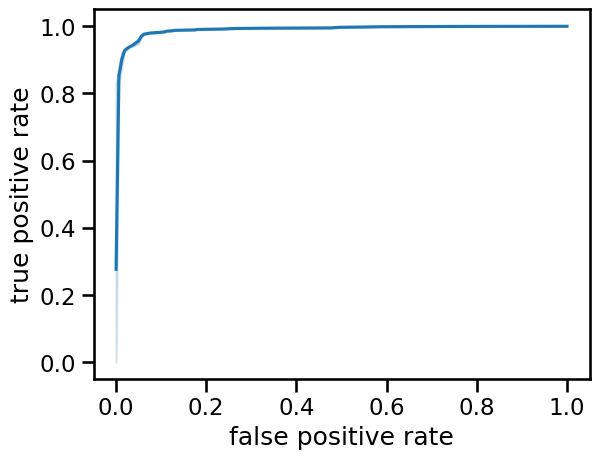

In [ ]:
# capiamo come parlare della ROC

y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC
fpr,tpr,thr = metrics.roc_curve(y_test,y_proba,pos_label='ok')
sns.set_context('talk')
ax = sns.lineplot(x=fpr, y=tpr)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')

# dato che abbiamo molti dati, la curva sembra quasi smooth

Text(0, 0.5, 'recall')

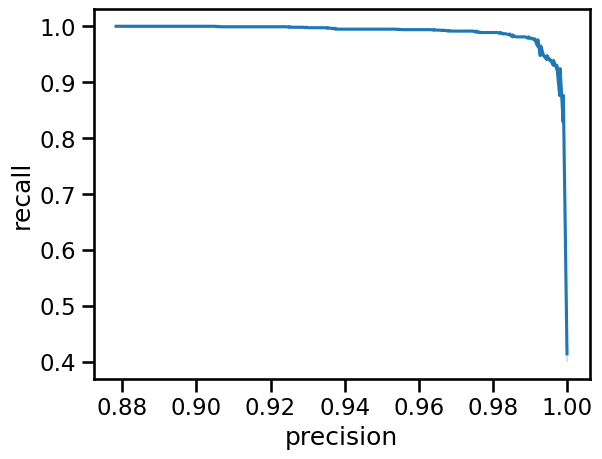

In [75]:
# plottiamo la curva precision-recall
prec,rec,thr = metrics.precision_recall_curve(y_test,y_proba,pos_label='ok')
sns.set_context('talk')
ax = sns.lineplot(x=prec, y=rec)
ax.set_xlabel('precision')
ax.set_ylabel('recall')

Text(0, 0.5, 'recall')

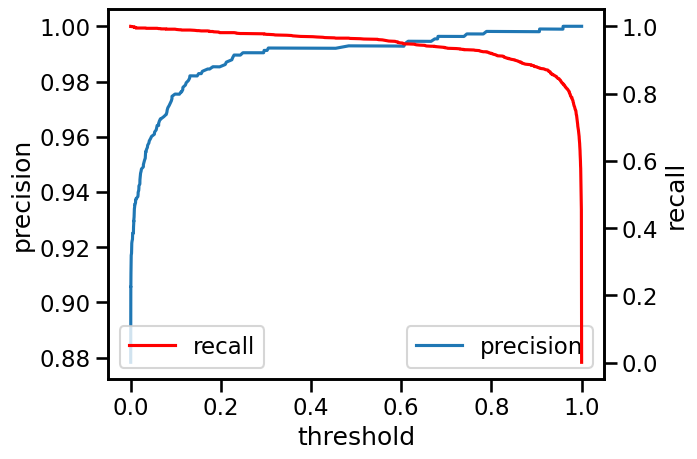

In [79]:
# plotto precision e recall separatamente al variare del threshold
ax = sns.lineplot(x=thr, y=prec[:-1], label='precision')
ax2 = sns.lineplot(x=thr,y=rec[:-1],label='recall',ax=ax.twinx(),color='red')
ax.set_xlabel('threshold')
ax.set_ylabel('precision')
ax2.set_ylabel('recall')

In [ ]:
# come aspettato, la precision = TP / PP aumenta all'aumentare del threshold, andando a 1 per il threshold che diventa 1
# per thr -> 1, TP -> 0 e PP -> 0 => prec -> 1, per thr -> 0, TP -> AP e PP -> n => prec -> AP / n != 0.5 se le classi sono sbilanciate
# al contrario, il recall = TP / AP diminuisce all'aumentare del threshold
# per thr -> 1, TP -> 0 e AP = const => rec -> 0, per thr -> 0, TP -> AP => rec -> 1

In [ ]:
# proviamo a capire quale sia il threshold migliore
# mi vengono in mente tre modi:
# 1) non volendo pesare differentemente una classe rispetto all'altra, una retta a pari performance nel grafico della ROC è una retta con coefficiente angolare
# P(N) / P(P) = #N / #P. Trovo il threshold che massimizza l'intercetta di questa retta (punto in cui la retta è tangente)

# 2) trovo il threshold che massimizza F1 (non sono sicuro funzioni bene per le classi non balanced)

# 3) trovo il threshold che massimizza il MCC (il MCC dovrebbe essere particolarmente buono per classi non bilanciate, come nel nostro caso)

0.22923054682380614


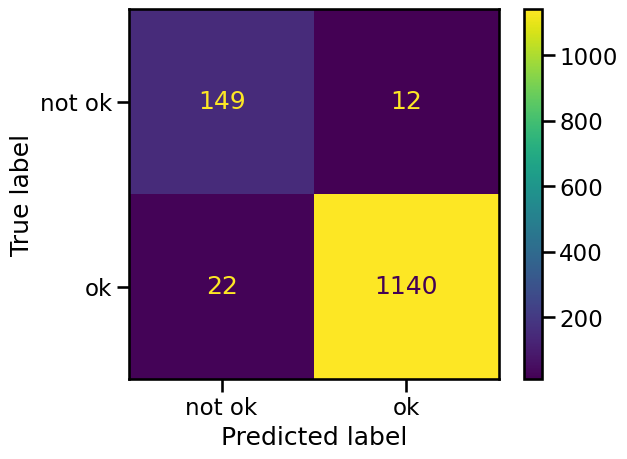

In [121]:
# 1)
num_N = (y_test == 'not ok').sum()
num_P = (y_test == 'ok').sum()

y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC
fpr,tpr,thr = metrics.roc_curve(y_test,y_proba,pos_label='ok')

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.1313145823033542


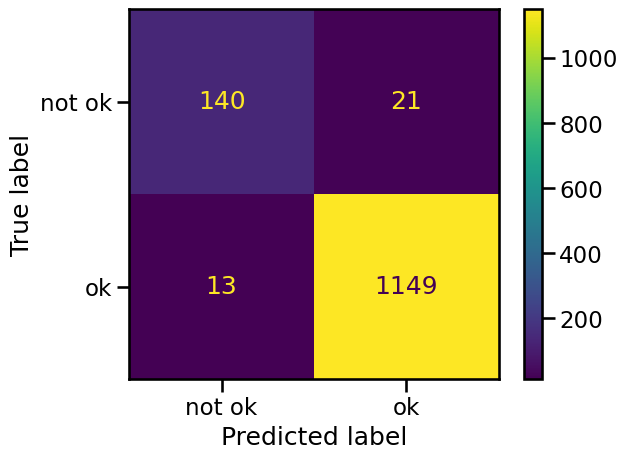

In [119]:
# 2)
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
f1_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    f1_score.append(2 * tp / (2 * tp + fp + fn))

best_idx = np.argmax(f1_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.22923054682380614


/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))
/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))


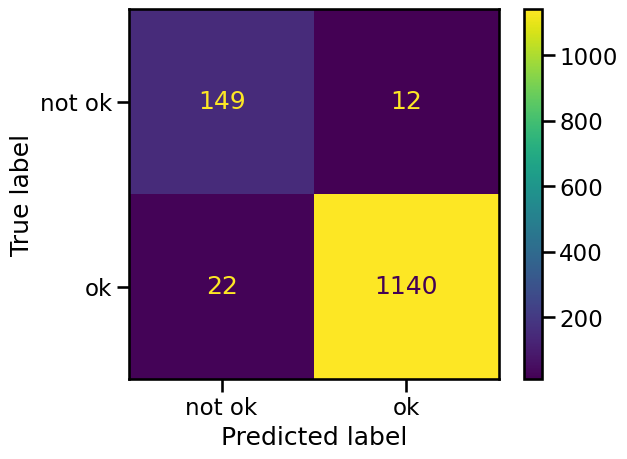

In [122]:
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
MCC_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    pp = tp + fp
    pn = tn + fn
    ap = tp + fn
    an = tn + fp
    MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))

best_idx = np.nanargmax(MCC_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()